# IPL 2022 Match Analysis — Capstone Project

### A practical EDA study using Python, Pandas and Seaborn

This project analyzes IPL 2022 match-level data to understand **team performance, toss decisions, scoring patterns, player contributions and venue trends**.  
Instead of looking at only one metric, I have combined multiple views of the same season to identify patterns that can be useful for a cricket analyst.

**Tools used:** Python • Pandas • NumPy • Matplotlib • Seaborn

**Level:** Undergraduate / 3rd Year Data Science


## Project Objectives

The main objectives of this analysis are:

1. Understand the structure and quality of the IPL 2022 dataset.
2. Identify the teams with the strongest match results.
3. Study whether the toss result is associated with the match result.
4. Compare chasing and defending performances.
5. Explore important batting and bowling contributions.
6. Analyze venues and scoring behavior.
7. Add a few custom insights beyond the basic questions.


## Dataset Overview

The dataset contains **74 IPL 2022 matches** and records match-level information such as date, venue, teams, toss result, innings scores, winner, victory margin, Player of the Match, top scorer and best bowling figures.

Some important variables are:

- `team1`, `team2` — teams involved in a match
- `toss_winner`, `toss_decision` — toss information
- `first_ings_score`, `second_ings_score` — innings scores
- `match_winner` — winning team
- `won_by`, `margin` — type and size of victory
- `player_of_the_match` — best performer of the match
- `top_scorer`, `highscore` — leading batting contribution
- `best_bowling`, `best_bowling_figure` — leading bowling contribution


## 1. Import Libraries and Load the Dataset

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid")

df = pd.read_csv("IPL.csv")
df.head()


,match_id,date,venue,team1,team2,stage,toss_winner,toss_decision,first_ings_score,first_ings_wkts,second_ings_score,second_ings_wkts,match_winner,won_by,margin,player_of_the_match,top_scorer,highscore,best_bowling,best_bowling_figure
0,1,"March 26,2022","Wankhede Stadium, Mumbai",Chennai,Kolkata,Group,Kolkata,Field,131,5,133,4,Kolkata,Wickets,6,Umesh Yadav,MS Dhoni,50,Dwayne Bravo,3--20
1,2,"March 27,2022","Brabourne Stadium, Mumbai",Delhi,Mumbai,Group,Delhi,Field,177,5,179,6,Delhi,Wickets,4,Kuldeep Yadav,Ishan Kishan,81,Kuldeep Yadav,3--18
2,3,"March 27,2022","Dr DY Patil Sports Academy, Mumbai",Banglore,Punjab,Group,Punjab,Field,205,2,208,5,Punjab,Wickets,5,Odean Smith,Faf du Plessis,88,Mohammed Siraj,2--59
3,4,"March 28,2022","Wankhede Stadium, Mumbai",Gujarat,Lucknow,Group,Gujarat,Field,158,6,161,5,Gujarat,Wickets,5,Mohammed Shami,Deepak Hooda,55,Mohammed Shami,3--25
4,5,"March 29,2022","Maharashtra Cricket Association Stadium,Pune",Hyderabad,Rajasthan,Group,Hyderabad,Field,210,6,149,7,Rajasthan,Runs,61,Sanju Samson,Aiden Markram,57,Yuzvendra Chahal,3--22


## 2. Initial Data Understanding

In [23]:
print("Dataset shape:", df.shape)
df.info()


Dataset shape: (74, 21)
<class 'pandas.DataFrame'>
RangeIndex: 74 entries, 0 to 73
Data columns (total 21 columns):
 #   Column               Non-Null Count  Dtype
---  ------               --------------  -----
 0   match_id             74 non-null     int64
 1   date                 74 non-null     str  
 2   venue                74 non-null     str  
 3   team1                74 non-null     str  
 4   team2                74 non-null     str  
 5   stage                74 non-null     str  
 6   toss_winner          74 non-null     str  
 7   toss_decision        74 non-null     str  
 8   first_ings_score     74 non-null     int64
 9   first_ings_wkts      74 non-null     int64
 10  second_ings_score    74 non-null     int64
 11  second_ings_wkts     74 non-null     int64
 12  match_winner         74 non-null     str  
 13  won_by               74 non-null     str  
 14  margin               74 non-null     int64
 15  player_of_the_match  74 non-null     str  
 16  top_scorer     

In [3]:
# Check missing values and duplicate rows
missing = df.isnull().sum().sort_values(ascending=False)
duplicates = df.duplicated().sum()

print("Total duplicate rows:", duplicates)
print("\nMissing values by column:")
print(missing)


Total duplicate rows: 0

Missing values by column:
match_id               0
date                   0
venue                  0
team1                  0
team2                  0
stage                  0
toss_winner            0
toss_decision          0
first_ings_score       0
first_ings_wkts        0
second_ings_score      0
second_ings_wkts       0
match_winner           0
won_by                 0
margin                 0
player_of_the_match    0
top_scorer             0
highscore              0
best_bowling           0
best_bowling_figure    0
dtype: int64


### Data Quality Check

The initial checks help confirm whether the dataset needs major cleaning before analysis.  
For this project, I also keep the original categorical values because they are useful for match-level grouping and comparison.


## 3. Team Performance

### Q1. Which teams won the most matches?

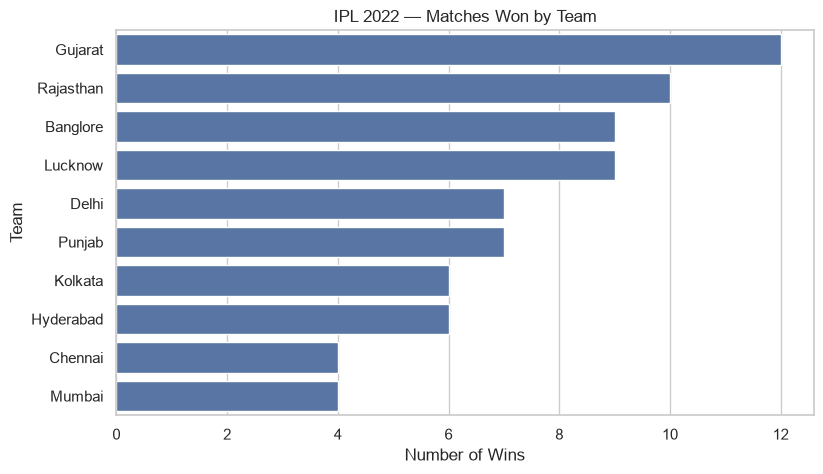

match_winner
Gujarat      12
Rajasthan    10
Banglore      9
Lucknow       9
Delhi         7
Punjab        7
Kolkata       6
Hyderabad     6
Chennai       4
Mumbai        4
Name: count, dtype: int64

In [4]:
match_wins = df["match_winner"].value_counts()

plt.figure(figsize=(9, 5))
sns.barplot(x=match_wins.values, y=match_wins.index)
plt.title("IPL 2022 — Matches Won by Team")
plt.xlabel("Number of Wins")
plt.ylabel("Team")
plt.show()

match_wins


### Q2. What percentage of matches did each team win?

In [5]:
win_percentage = (match_wins / len(df) * 100).round(2)
win_summary = pd.DataFrame({
    "Wins": match_wins,
    "Win % of all matches": win_percentage
})
win_summary


,Wins,Win % of all matches
match_winner,,
Gujarat,12,16.22
Rajasthan,10,13.51
Banglore,9,12.16
Lucknow,9,12.16
Delhi,7,9.46
Punjab,7,9.46
Kolkata,6,8.11
Hyderabad,6,8.11
Chennai,4,5.41


**Observation:** Gujarat recorded the highest number of wins in this dataset, followed by Rajasthan. This gives a quick view of which teams were most successful across the 2022 season.


## 4. Toss Analysis

### Q3. What was the most common toss decision?

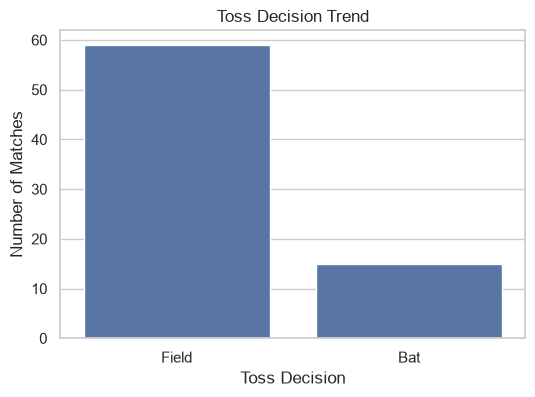

toss_decision
Field    59
Bat      15
Name: count, dtype: int64

In [6]:
toss_decision_counts = df["toss_decision"].value_counts()

plt.figure(figsize=(6, 4))
sns.barplot(x=toss_decision_counts.index, y=toss_decision_counts.values)
plt.title("Toss Decision Trend")
plt.xlabel("Toss Decision")
plt.ylabel("Number of Matches")
plt.show()

toss_decision_counts


### Q4. How often did the toss winner also win the match?

In [7]:
toss_match_wins = (df["toss_winner"] == df["match_winner"]).sum()
toss_win_rate = round(toss_match_wins / len(df) * 100, 2)

print(f"Toss winner also won the match in {toss_match_wins} out of {len(df)} matches.")
print(f"Percentage: {toss_win_rate}%")


Toss winner also won the match in 36 out of 74 matches.
Percentage: 48.65%


### Q5. Does the toss decision appear to affect the final result?

In [8]:
toss_result_table = pd.crosstab(
    df["toss_decision"],
    df["won_by"],
    margins=True
)
toss_result_table


won_by,Runs,Wickets,All
toss_decision,,,
Bat,7,8,15
Field,30,29,59
All,37,37,74


**Interpretation:** Toss results can influence the decision to bat or field, but the toss alone does not guarantee a match victory. Team execution, scoring pressure and bowling performance remain important factors.


## 5. How Were Matches Won?

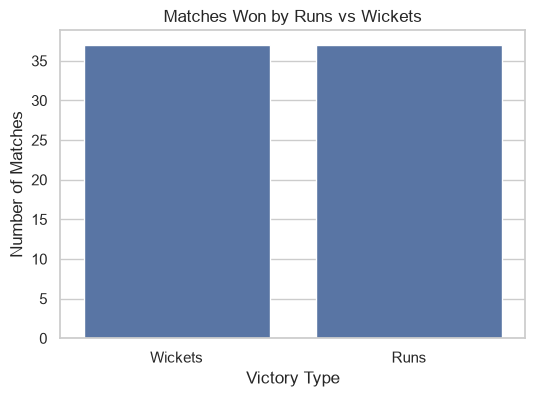

won_by
Wickets    37
Runs       37
Name: count, dtype: int64

In [9]:
win_type = df["won_by"].value_counts()

plt.figure(figsize=(6, 4))
sns.barplot(x=win_type.index, y=win_type.values)
plt.title("Matches Won by Runs vs Wickets")
plt.xlabel("Victory Type")
plt.ylabel("Number of Matches")
plt.show()

win_type


## 6. Batting Performance

### Top Players by Recorded Individual Score

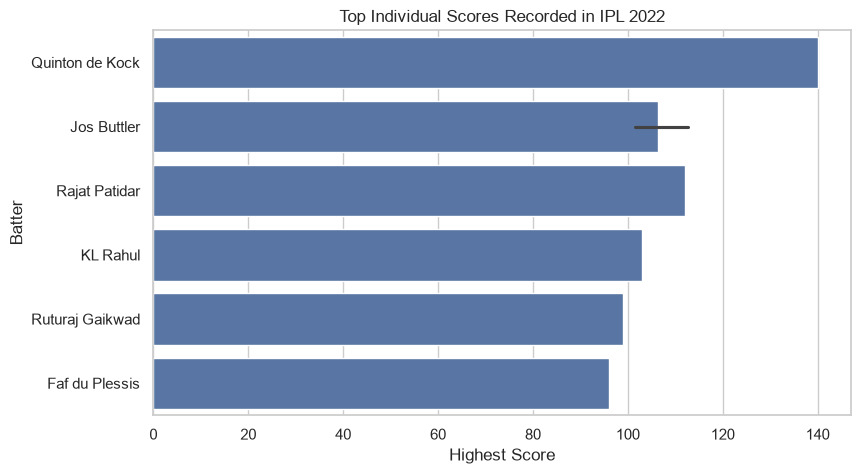

,top_scorer,highscore
65,Quinton de Kock,140
33,Jos Buttler,116
71,Rajat Patidar,112
72,Jos Buttler,106
25,KL Rahul,103
29,Jos Buttler,103
36,KL Rahul,103
8,Jos Buttler,100
45,Ruturaj Gaikwad,99
30,Faf du Plessis,96


In [10]:
top_scores = (
    df[["top_scorer", "highscore"]]
    .sort_values("highscore", ascending=False)
    .head(10)
)

plt.figure(figsize=(9, 5))
sns.barplot(data=top_scores, x="highscore", y="top_scorer")
plt.title("Top Individual Scores Recorded in IPL 2022")
plt.xlabel("Highest Score")
plt.ylabel("Batter")
plt.show()

top_scores


### Which players appeared most often as the top scorer?

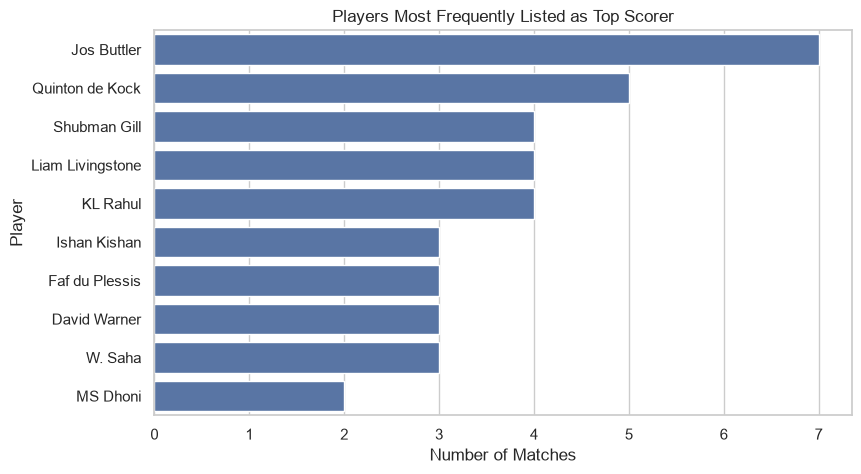

In [11]:
top_scorer_frequency = df["top_scorer"].value_counts().head(10)

plt.figure(figsize=(9, 5))
sns.barplot(x=top_scorer_frequency.values, y=top_scorer_frequency.index)
plt.title("Players Most Frequently Listed as Top Scorer")
plt.xlabel("Number of Matches")
plt.ylabel("Player")
plt.show()


## 7. Player of the Match Analysis

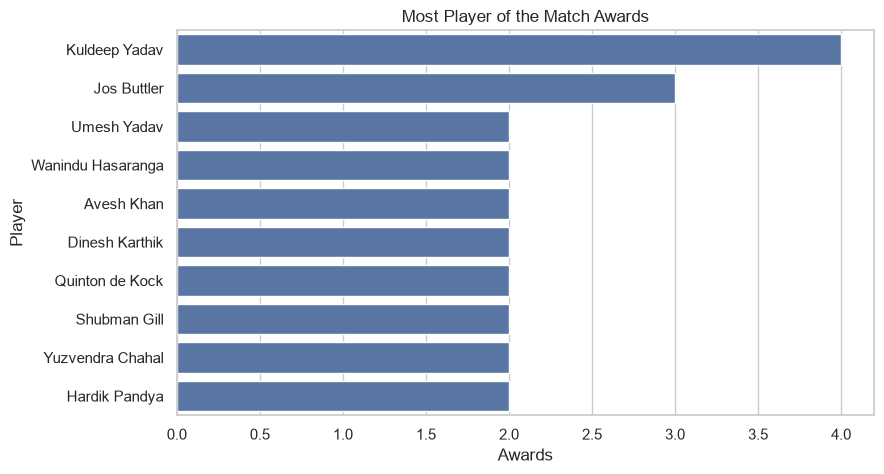

player_of_the_match
Kuldeep Yadav        4
Jos Buttler          3
Umesh Yadav          2
Wanindu Hasaranga    2
Avesh Khan           2
Dinesh Karthik       2
Quinton de Kock      2
Shubman Gill         2
Yuzvendra Chahal     2
Hardik Pandya        2
Name: count, dtype: int64

In [12]:
pom = df["player_of_the_match"].value_counts().head(10)

plt.figure(figsize=(9, 5))
sns.barplot(x=pom.values, y=pom.index)
plt.title("Most Player of the Match Awards")
plt.xlabel("Awards")
plt.ylabel("Player")
plt.show()

pom


## 8. Bowling Performance

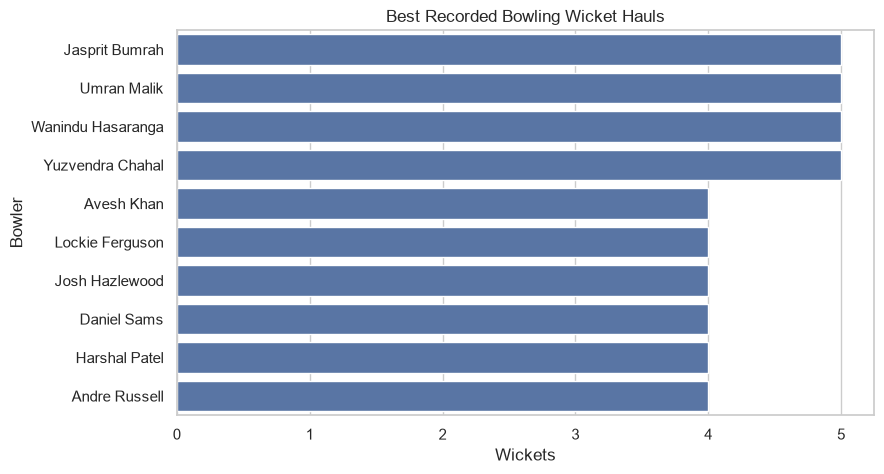

best_bowling
Jasprit Bumrah       5
Umran Malik          5
Wanindu Hasaranga    5
Yuzvendra Chahal     5
Avesh Khan           4
Lockie Ferguson      4
Josh Hazlewood       4
Daniel Sams          4
Harshal Patel        4
Andre Russell        4
Name: wickets_taken, dtype: int64

In [13]:
# Extract wickets from figures such as 3--20 or 4--25
df["wickets_taken"] = (
    df["best_bowling_figure"]
    .astype(str)
    .str.split("--")
    .str[0]
    .astype(int)
)

bowling_summary = (
    df.groupby("best_bowling")["wickets_taken"]
    .max()
    .sort_values(ascending=False)
    .head(10)
)

plt.figure(figsize=(9, 5))
sns.barplot(x=bowling_summary.values, y=bowling_summary.index)
plt.title("Best Recorded Bowling Wicket Hauls")
plt.xlabel("Wickets")
plt.ylabel("Bowler")
plt.show()

bowling_summary


## 9. Venue Analysis

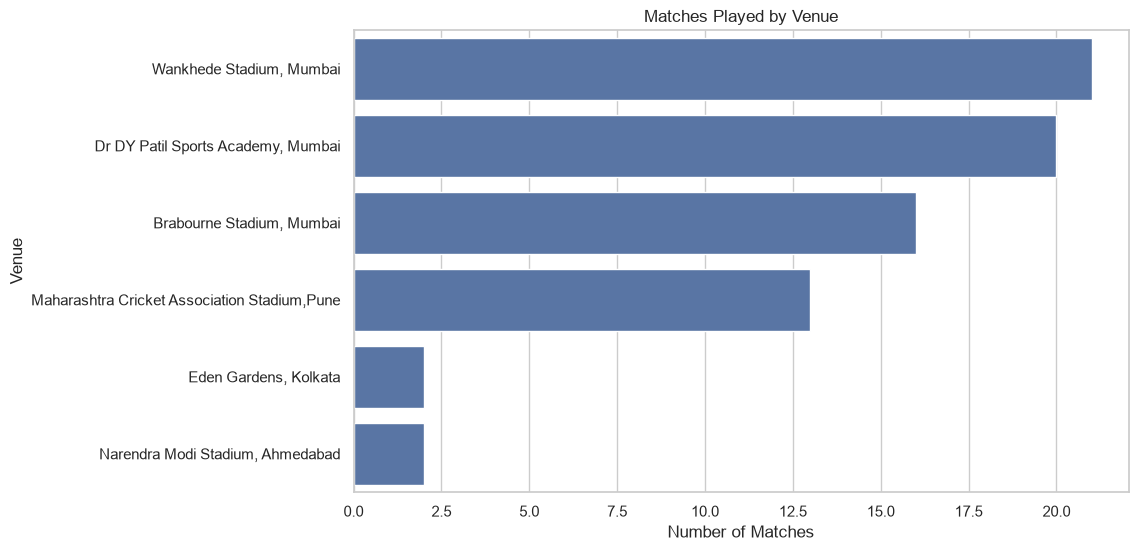

venue
Wankhede Stadium, Mumbai                        21
Dr DY Patil Sports Academy, Mumbai              20
Brabourne Stadium, Mumbai                       16
Maharashtra Cricket Association Stadium,Pune    13
Eden Gardens, Kolkata                            2
Narendra Modi Stadium, Ahmedabad                 2
Name: count, dtype: int64

In [14]:
venue_count = df["venue"].value_counts()

plt.figure(figsize=(10, 6))
sns.barplot(x=venue_count.values, y=venue_count.index)
plt.title("Matches Played by Venue")
plt.xlabel("Number of Matches")
plt.ylabel("Venue")
plt.show()

venue_count


### Average First-Innings Score by Venue

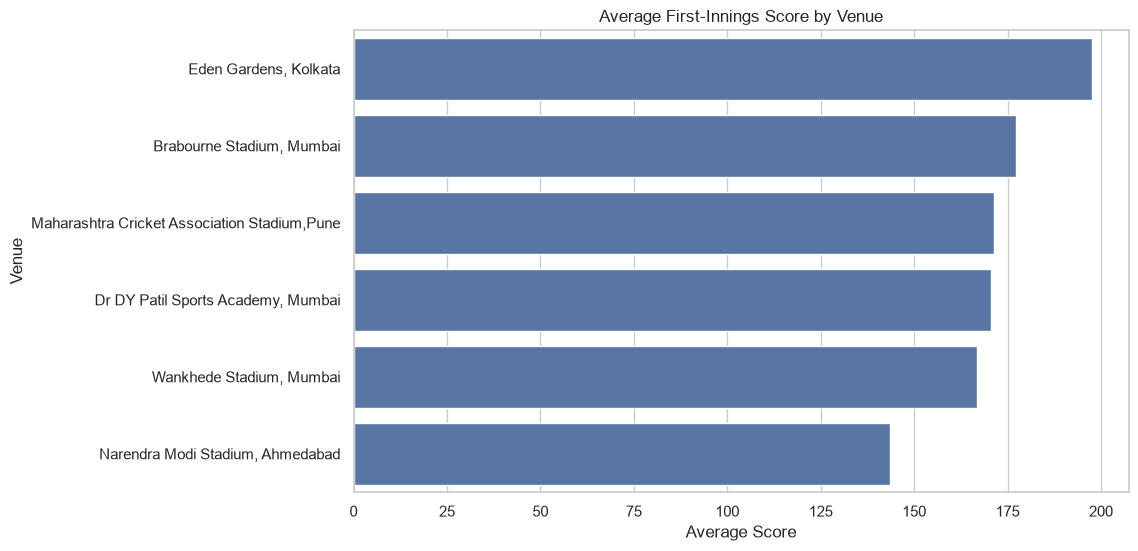

venue
Eden Gardens, Kolkata                           197.50
Brabourne Stadium, Mumbai                       177.25
Maharashtra Cricket Association Stadium,Pune    171.46
Dr DY Patil Sports Academy, Mumbai              170.70
Wankhede Stadium, Mumbai                        166.76
Narendra Modi Stadium, Ahmedabad                143.50
Name: first_ings_score, dtype: float64

In [15]:
venue_scores = (
    df.groupby("venue")["first_ings_score"]
    .mean()
    .sort_values(ascending=False)
)

plt.figure(figsize=(10, 6))
sns.barplot(x=venue_scores.values, y=venue_scores.index)
plt.title("Average First-Innings Score by Venue")
plt.xlabel("Average Score")
plt.ylabel("Venue")
plt.show()

venue_scores.round(2)


## 10. Score Distribution and Match Intensity

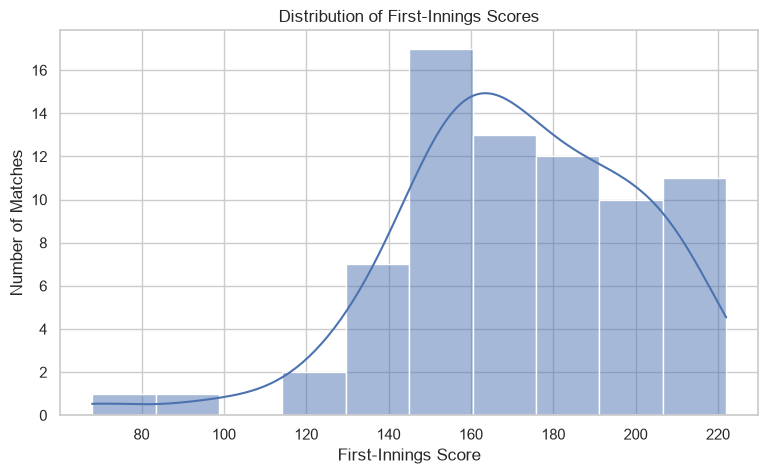

In [16]:
plt.figure(figsize=(9, 5))
sns.histplot(df["first_ings_score"], bins=10, kde=True)
plt.title("Distribution of First-Innings Scores")
plt.xlabel("First-Innings Score")
plt.ylabel("Number of Matches")
plt.show()


### First vs Second Innings Score

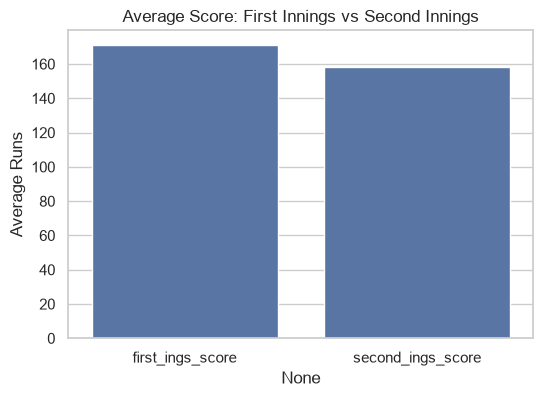

first_ings_score     171.12
second_ings_score    158.54
dtype: float64

In [17]:
score_comparison = df[["first_ings_score", "second_ings_score"]].mean()

plt.figure(figsize=(6, 4))
sns.barplot(x=score_comparison.index, y=score_comparison.values)
plt.title("Average Score: First Innings vs Second Innings")
plt.ylabel("Average Runs")
plt.show()

score_comparison.round(2)


## 11. Custom Insights

### Q1. What was the biggest victory by runs?

In [18]:
largest_run_win = (
    df[df["won_by"] == "Runs"]
    .sort_values("margin", ascending=False)
    .head(1)
)

largest_run_win[["match_id", "match_winner", "margin", "venue"]]


,match_id,match_winner,margin,venue
54,55,Chennai,91,"Dr DY Patil Sports Academy, Mumbai"


### Q2. Which player recorded the highest individual score?

In [19]:
highest_score = df.loc[
    df["highscore"].idxmax(),
    ["top_scorer", "highscore", "match_id"]
]

highest_score


top_scorer    Quinton de Kock
highscore                 140
match_id                   66
Name: 65, dtype: object

### Q3. Who produced the best wicket haul?

In [20]:
best_bowling_match = df.loc[
    df["wickets_taken"].idxmax(),
    ["best_bowling", "best_bowling_figure", "match_id"]
]

best_bowling_match


best_bowling           Yuzvendra Chahal
best_bowling_figure               5--40
match_id                             30
Name: 29, dtype: object

### Q4. Which matches had the closest finishes by runs?

In [21]:
closest_run_wins = (
    df[df["won_by"] == "Runs"]
    .sort_values("margin", ascending=True)
    .head(5)
)

closest_run_wins[["match_id", "match_winner", "margin", "venue"]]


,match_id,match_winner,margin,venue
65,66,Lucknow,2,"Dr DY Patil Sports Academy, Mumbai"
19,20,Rajasthan,3,"Wankhede Stadium, Mumbai"
64,65,Hyderabad,3,"Wankhede Stadium, Mumbai"
50,51,Mumbai,5,"Brabourne Stadium, Mumbai"
44,45,Lucknow,6,"Wankhede Stadium, Mumbai"


### Q5. Which team had the highest average first-innings score when batting first?

In [22]:
team_first_innings_avg = (
    df.groupby("team1")["first_ings_score"]
    .mean()
    .sort_values(ascending=False)
    .round(2)
)

team_first_innings_avg


team1
Punjab       189.00
Mumbai       183.00
Hyderabad    176.00
Kolkata      174.00
Delhi        172.92
Banglore     170.44
Gujarat      169.00
Lucknow      167.83
Chennai      164.67
Name: first_ings_score, dtype: float64

## 12. Key Findings

Based on the exploratory data analysis:

- Gujarat had the strongest match-winning record in the dataset.
- Choosing to field after winning the toss was a common strategy.
- Winning the toss and winning the match are related observations, but they are not the same thing.
- Both batting and bowling performances contributed strongly to match outcomes.
- A small number of players appeared repeatedly among top individual performances.
- Venue-level averages show that scoring conditions can differ across grounds.
- Match margins help distinguish comfortable wins from close contests.

### Limitations

This is a **match-level IPL 2022 analysis**, so it does not contain ball-by-ball information. Therefore, detailed metrics such as strike rate by phase, economy by over, powerplay performance and player consistency cannot be calculated reliably from these columns alone.

## Conclusion

This project demonstrates how Python can be used to move from raw sports data to meaningful exploratory insights. The analysis combines data-quality checks, descriptive statistics and visualizations to understand team, toss, player and venue patterns in IPL 2022.

The next step could be to extend this project with **ball-by-ball IPL data**, build a team-strength model, or create a machine-learning model to predict match winners.
